# MWE 13 - Synthetic porous-volume benchmark against XLB

This notebook generates fifteen synthetic segmented spanning volumes with `voids`, solves them
directly on the binary image with XLB, extracts pore networks with `snow2`, and compares `Kabs`
estimates between the direct-image voxel-scale LBM reference and the extracted-network PNM
workflow.

The notebook also makes the XLB model explicit. The current adapter uses XLB's incompressible
Navier-Stokes lattice-Boltzmann stepper. A separate "steady Stokes limit" study is included
below, but that mode still uses the same lattice-Boltzmann operator with milder forcing and
tighter steady-state controls; it is not a different upstream Stokes-only discretization.

Scientific scope and assumptions:
- the benchmark works on binary segmented images directly; it does not include scanner-physics
  emulation or a grayscale segmentation step
- the benchmark wrapper now couples the same physical pressure drop to both PNM and XLB; the XLB
  side converts that shared $\Delta p$ to lattice pressure units before applying the boundary
  conditions
- the XLB solve adds short fluid reservoir layers ahead of and behind the sample so the imposed
  pressure boundary conditions live on clean planar faces rather than directly on a perforated
  porous inlet/outlet surface
- the `voids` side uses `snow2` extraction plus the selected hydraulic conductance model, so any
  mismatch reflects both extraction loss and PNM constitutive simplification
- side faces orthogonal to the flow axis are treated as sealed sample walls in the direct-image
  XLB solve, which matches the intended core-flood-style interpretation of the benchmark
- XLB is an optional dependency; run this notebook in the Pixi `lbm` environment

## Governing models and equations

The extracted-network `voids` solve and the direct-image XLB solve are not equivalent models, so
the verification only makes sense if the formulations are explicit.

`voids` solves the pore-network pressure problem

$$
\mathbf{A}\,\mathbf{p} = \mathbf{b},
$$

with throat fluxes

$$
q_t = g_t (p_i - p_j),
$$

and apparent permeability from Darcy's law

$$
K = \frac{|Q|\,\mu\,L}{A\,|\Delta p|}.
$$

The XLB side advances discrete particle populations $f_i(\mathbf{x}, t)$ on a D3Q19 lattice
using the BGK collision model:

$$
f_i(\mathbf{x} + \mathbf{c}_i \Delta t, t + \Delta t)
=
f_i(\mathbf{x}, t)
- \omega \left[f_i(\mathbf{x}, t) - f_i^{\mathrm{eq}}(\rho, \mathbf{u})\right].
$$

The macroscopic moments are

$$
\rho = \sum_i f_i, \qquad
\rho \mathbf{u} = \sum_i \mathbf{c}_i f_i,
$$

with the standard quadratic equilibrium

$$
f_i^{\mathrm{eq}}
=
w_i \rho
\left[
1
+ \frac{\mathbf{c}_i \cdot \mathbf{u}}{c_s^2}
+ \frac{(\mathbf{c}_i \cdot \mathbf{u})^2}{2 c_s^4}
- \frac{\mathbf{u} \cdot \mathbf{u}}{2 c_s^2}
\right].
$$

In lattice units, the kinematic viscosity is

$$
\nu_{\mathrm{lu}} = c_s^2 \left(\tau - \frac{1}{2}\right),
\qquad
\omega = \tau^{-1}.
$$

In this isothermal formulation, lattice pressure is tied to density through

$$
p_{\mathrm{lu}} = c_s^2 \rho.
$$

XLB's boundary operator still expects the equivalent density values, but the public `voids`
adapter now accepts pressure BCs and converts them internally with this relation.

To couple the same physical pressure drop to PNM and LBM, we use the standard unit conversion

$$
\nu_{\mathrm{phys}} = \frac{\mu_{\mathrm{phys}}}{\rho_{\mathrm{phys}}},
\qquad
\Delta t_{\mathrm{phys}}
=
\frac{
  \nu_{\mathrm{lu}}\,\Delta x_{\mathrm{phys}}^2
}{
  \nu_{\mathrm{phys}}
},
$$

followed by

$$
\Delta p_{\mathrm{lu}}
=
\Delta p_{\mathrm{phys}}
\frac{
  \Delta t_{\mathrm{phys}}^2
}{
  \rho_{\mathrm{phys}}\,\Delta x_{\mathrm{phys}}^2
}.
$$

This is the important consistency point for the benchmark: the `voids` side and the XLB side
now use the same imposed physical $\Delta p$ within each comparison mode, while XLB still applies
that pressure drop through its equivalent lattice densities.

For the current incompressible permeability benchmark, the absolute pressure offset is only a
gauge choice. The preferred public high-level input is therefore `delta_p`, typically in Pa.
Passing `delta_p = 1`, `pin = 1` / `pout = 0`, or `delta_p = 1` together with
`pin = 101326` / `pout = 101325` all represent the same present benchmark driving condition.

The direct-image permeability mapping used in this notebook is

$$
K_{\mathrm{phys}} =
\frac{
\nu_{\mathrm{lu}}\,U_{\mathrm{lu}}\,L_{\mathrm{lu}}\,\Delta x_{\mathrm{phys}}^2
}{
\Delta p_{\mathrm{lu}}
},
\qquad
\Delta p_{\mathrm{lu}} = p_{\mathrm{in,lu}} - p_{\mathrm{out,lu}}.
$$

In the low-Mach, low-Reynolds, steady limit, the recovered continuum problem is the
incompressible Stokes system in the pore space:

$$
-\nabla p + \mu \nabla^2 \mathbf{u} = \mathbf{0},
\qquad
\nabla \cdot \mathbf{u} = 0
\quad \text{in the void voxels},
$$

with no-slip walls imposed here through half-way bounce-back on solid voxels. The
`steady_stokes_limit` preset below therefore targets the creeping-flow limit of the same LBM
operator; it does not switch to a separate Stokes solver inside XLB.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from voids.benchmarks import XLBOptions, benchmark_segmented_volume_with_xlb
from voids.generators import generate_spanning_blobs_matrix
from voids.physics.singlephase import FluidSinglePhase, SinglePhaseOptions

In [2]:
flow_axis = "x"
axis_index = 0
voxel_size = 2.0e-6
options = SinglePhaseOptions(
    conductance_model="valvatne_blunt_baseline",
    solver="direct",
)
benchmark_delta_p = 25.0 / 3.0
stokes_delta_p = 5.0 / 3.0
fluid = FluidSinglePhase(viscosity=1.0e-3, density=1.0e3)
benchmark_xlb_options = XLBOptions(
    max_steps=3000,
    min_steps=400,
    check_interval=50,
    steady_rtol=1.0e-3,
    lattice_viscosity=0.10,
    inlet_outlet_buffer_cells=6,
)
stokes_xlb_options = XLBOptions.steady_stokes_defaults(
    max_steps=3000,
    min_steps=800,
    check_interval=50,
)


def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "mkdocs.yml").exists() and (candidate / "docs").exists():
            return candidate
    return cwd


def _make_permeability_comparison_figure(
    summary_frame: pd.DataFrame,
    *,
    k_col: str,
    rel_diff_col: str,
    xlb_label: str,
    title: str,
    output_path: Path,
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    kmin = float(min(summary_frame["k_voids"].min(), summary_frame[k_col].min()))
    kmax = float(max(summary_frame["k_voids"].max(), summary_frame[k_col].max()))
    pad = 0.05 * max(kmax - kmin, 1.0e-30)

    axes[0].scatter(
        summary_frame[k_col], summary_frame["k_voids"], s=60, color="tab:blue"
    )
    axes[0].plot(
        [kmin - pad, kmax + pad],
        [kmin - pad, kmax + pad],
        color="black",
        lw=1.2,
        linestyle="--",
    )
    axes[0].set_xlabel(f"{xlb_label} permeability [m$^2$]")
    axes[0].set_ylabel("voids permeability [m$^2$]")
    axes[0].set_title("Permeability scatter")

    axes[1].bar(summary_frame["case"], summary_frame[rel_diff_col], color="tab:orange")
    axes[1].set_xlabel("case")
    axes[1].set_ylabel("relative difference [%]")
    axes[1].set_title("Per-case permeability mismatch")
    axes[1].tick_params(axis="x", rotation=25)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()


def _make_porosity_trend_figure(
    summary_frame: pd.DataFrame,
    *,
    k_col: str,
    xlb_label: str,
    title: str,
    output_path: Path,
) -> None:
    plot_df = summary_frame.sort_values(["phi_image", "blobiness"]).copy()
    fig, ax = plt.subplots(figsize=(7.5, 4.8))

    ax.semilogy(
        plot_df["phi_image"],
        plot_df[k_col],
        marker="o",
        lw=1.5,
        label=xlb_label,
    )
    ax.semilogy(
        plot_df["phi_image"],
        plot_df["k_voids"],
        marker="s",
        lw=1.5,
        label="voids",
    )
    ax.set_xlabel("image porosity [-]")
    ax.set_ylabel("permeability [m$^2$]")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()


project_root = _find_project_root()
report_dir = project_root / "docs" / "assets" / "verification"
report_dir.mkdir(parents=True, exist_ok=True)
report_csv = report_dir / "xlb_15_case_results.csv"
stokes_report_csv = report_dir / "xlb_stokes_15_case_results.csv"
comparison_figure_path = report_dir / "xlb_permeability_scatter_and_error.png"
porosity_figure_path = report_dir / "xlb_porosity_vs_permeability.png"
stokes_csv_path = report_dir / "xlb_stokes_limit_representative.csv"
stokes_comparison_figure_path = (
    report_dir / "xlb_stokes_permeability_scatter_and_error.png"
)
stokes_porosity_figure_path = report_dir / "xlb_stokes_porosity_vs_permeability.png"
benchmark_vs_stokes_figure_path = report_dir / "xlb_benchmark_vs_stokes_limit.png"

## Numerical setup

The 15-case sweep below uses the standard benchmark configuration. It still solves a steady
pressure-driven, incompressible LBM problem, but with a slightly larger shared pressure drop than
the later creeping-flow demonstration to keep the full notebook runtime reasonable.

- `formulation = "incompressible_navier_stokes"`
- D3Q19 velocity set
- `collision_model = "BGK"`
- `streaming_scheme = "pull"`
- `nu_lu = 0.10`
- preferred physical benchmark input `delta_p = 25/3 Pa`, mapped here to `Δp_lu = 3.333e-4`
- the notebook uses the default gauge choice `pout = 0 Pa`, `pin = delta_p`
- `inlet_outlet_buffer_cells = 6`

The later Stokes-limit section reuses the same geometry and solver, but uses the smaller shared
drop `delta_p = 5/3 Pa`, which maps to `Δp_lu = 6.667e-5` for the same fluid and voxel size.

In [3]:
case_specs = [
    {
        "case": "phi028_b12",
        "shape": (24, 24, 24),
        "porosity": 0.28,
        "blobiness": 1.2,
        "seed_start": 101,
    },
    {
        "case": "phi028_b14",
        "shape": (24, 24, 24),
        "porosity": 0.28,
        "blobiness": 1.4,
        "seed_start": 135,
    },
    {
        "case": "phi028_b15",
        "shape": (24, 24, 24),
        "porosity": 0.28,
        "blobiness": 1.5,
        "seed_start": 152,
    },
    {
        "case": "phi032_b12",
        "shape": (24, 24, 24),
        "porosity": 0.32,
        "blobiness": 1.2,
        "seed_start": 271,
    },
    {
        "case": "phi032_b14",
        "shape": (24, 24, 24),
        "porosity": 0.32,
        "blobiness": 1.4,
        "seed_start": 305,
    },
    {
        "case": "phi032_b15",
        "shape": (24, 24, 24),
        "porosity": 0.32,
        "blobiness": 1.5,
        "seed_start": 322,
    },
    {
        "case": "phi036_b12",
        "shape": (24, 24, 24),
        "porosity": 0.36,
        "blobiness": 1.2,
        "seed_start": 441,
    },
    {
        "case": "phi036_b14",
        "shape": (24, 24, 24),
        "porosity": 0.36,
        "blobiness": 1.4,
        "seed_start": 475,
    },
    {
        "case": "phi036_b15",
        "shape": (24, 24, 24),
        "porosity": 0.36,
        "blobiness": 1.5,
        "seed_start": 492,
    },
    {
        "case": "phi040_b12",
        "shape": (24, 24, 24),
        "porosity": 0.40,
        "blobiness": 1.2,
        "seed_start": 611,
    },
    {
        "case": "phi040_b14",
        "shape": (24, 24, 24),
        "porosity": 0.40,
        "blobiness": 1.4,
        "seed_start": 645,
    },
    {
        "case": "phi040_b15",
        "shape": (24, 24, 24),
        "porosity": 0.40,
        "blobiness": 1.5,
        "seed_start": 662,
    },
    {
        "case": "phi044_b12",
        "shape": (24, 24, 24),
        "porosity": 0.44,
        "blobiness": 1.2,
        "seed_start": 781,
    },
    {
        "case": "phi044_b14",
        "shape": (24, 24, 24),
        "porosity": 0.44,
        "blobiness": 1.4,
        "seed_start": 815,
    },
    {
        "case": "phi044_b15",
        "shape": (24, 24, 24),
        "porosity": 0.44,
        "blobiness": 1.5,
        "seed_start": 832,
    },
]
case_specs

[{'case': 'phi028_b12',
  'shape': (24, 24, 24),
  'porosity': 0.28,
  'blobiness': 1.2,
  'seed_start': 101},
 {'case': 'phi028_b14',
  'shape': (24, 24, 24),
  'porosity': 0.28,
  'blobiness': 1.4,
  'seed_start': 135},
 {'case': 'phi028_b15',
  'shape': (24, 24, 24),
  'porosity': 0.28,
  'blobiness': 1.5,
  'seed_start': 152},
 {'case': 'phi032_b12',
  'shape': (24, 24, 24),
  'porosity': 0.32,
  'blobiness': 1.2,
  'seed_start': 271},
 {'case': 'phi032_b14',
  'shape': (24, 24, 24),
  'porosity': 0.32,
  'blobiness': 1.4,
  'seed_start': 305},
 {'case': 'phi032_b15',
  'shape': (24, 24, 24),
  'porosity': 0.32,
  'blobiness': 1.5,
  'seed_start': 322},
 {'case': 'phi036_b12',
  'shape': (24, 24, 24),
  'porosity': 0.36,
  'blobiness': 1.2,
  'seed_start': 441},
 {'case': 'phi036_b14',
  'shape': (24, 24, 24),
  'porosity': 0.36,
  'blobiness': 1.4,
  'seed_start': 475},
 {'case': 'phi036_b15',
  'shape': (24, 24, 24),
  'porosity': 0.36,
  'blobiness': 1.5,
  'seed_start': 492},
 

## Generate binary benchmark cases and compare `voids` against XLB

Each case is a percolating segmented void image. XLB sees the binary image directly, while `voids`
extracts a spanning pore network from the same image before solving. Within each comparison mode,
both methods use the same physical pressure drop:

- benchmark mode: $\Delta p = 25/3 \ \mathrm{Pa} \approx 8.333 \ \mathrm{Pa}$
- steady Stokes limit: $\Delta p = 5/3 \ \mathrm{Pa} \approx 1.667 \ \mathrm{Pa}$

In the notebook calls below, these are passed as `delta_p` values. The wrappers then use the
default gauge choice `pout = 0`, `pin = delta_p`. For the chosen fluid and voxel size, those map
to the same lattice pressure drops used in the earlier benchmark implementation. The notebook also
writes a CSV summary and figure assets used by the documentation report under
`docs/assets/verification/`.

In [4]:
benchmark_rows: list[dict[str, object]] = []
stokes_rows: list[dict[str, object]] = []
case_artifacts: dict[str, dict[str, object]] = {}

for case in case_specs:
    segmented, seed_used = generate_spanning_blobs_matrix(
        shape=case["shape"],
        porosity=case["porosity"],
        blobiness=case["blobiness"],
        axis_index=axis_index,
        seed_start=case["seed_start"],
        max_tries=30,
    )

    benchmark = benchmark_segmented_volume_with_xlb(
        segmented,
        voxel_size=voxel_size,
        flow_axis=flow_axis,
        fluid=fluid,
        delta_p=benchmark_delta_p,
        options=options,
        xlb_options=benchmark_xlb_options,
        provenance_notes={
            "benchmark_case": case["case"],
            "seed_used": seed_used,
        },
    )

    record = benchmark.to_record()
    stokes_benchmark = benchmark_segmented_volume_with_xlb(
        segmented,
        voxel_size=voxel_size,
        flow_axis=flow_axis,
        fluid=fluid,
        delta_p=stokes_delta_p,
        options=options,
        xlb_options=stokes_xlb_options,
        provenance_notes={
            "benchmark_case": case["case"],
            "seed_used": seed_used,
            "mode": "steady_stokes_limit",
        },
    )
    stokes_record = stokes_benchmark.to_record()
    stokes_result = stokes_benchmark.xlb_result
    benchmark_rows.append(
        {
            **case,
            "seed_used": int(seed_used),
            **record,
            "k_ratio_voids_to_xlb": float(record["k_voids"]) / float(record["k_xlb"]),
            "k_rel_diff_pct": 100.0 * float(record["k_rel_diff"]),
        }
    )
    stokes_rows.append(
        {
            **case,
            "seed_used": int(seed_used),
            "flow_axis": benchmark.extract.flow_axis,
            "phi_image": float(benchmark.image_porosity),
            "phi_abs": float(benchmark.absolute_porosity),
            "phi_eff": float(benchmark.effective_porosity),
            "Np": int(benchmark.extract.net.Np),
            "Nt": int(benchmark.extract.net.Nt),
            "k_voids": float(stokes_record["k_voids"]),
            "k_xlb_stokes": float(stokes_record["k_xlb"]),
            "k_abs_diff_stokes": abs(
                float(stokes_record["k_voids"]) - float(stokes_record["k_xlb"])
            ),
            "k_rel_diff_stokes": abs(
                float(stokes_record["k_voids"]) - float(stokes_record["k_xlb"])
            )
            / max(
                abs(float(stokes_record["k_voids"])),
                abs(float(stokes_record["k_xlb"])),
                1.0e-30,
            ),
            "k_ratio_voids_to_stokes": float(stokes_record["k_voids"])
            / float(stokes_record["k_xlb"]),
            "dp_physical_stokes": float(stokes_record["dp_physical"]),
            "xlb_dp_lattice_stokes": float(stokes_record["xlb_dp_lattice"]),
            "xlb_steps_stokes": int(stokes_result.n_steps),
            "xlb_converged_stokes": bool(stokes_result.converged),
            "xlb_convergence_metric_stokes": float(stokes_result.convergence_metric),
            "xlb_formulation_stokes": str(stokes_result.formulation),
            "xlb_mach_max_stokes": float(stokes_result.max_mach_lattice),
            "xlb_re_voxel_max_stokes": float(stokes_result.reynolds_voxel_max),
            "k_xlb_benchmark": float(record["k_xlb"]),
            "k_xlb_rel_diff_pct_benchmark_vs_stokes": 100.0
            * abs(float(stokes_result.permeability) - float(record["k_xlb"]))
            / max(abs(float(record["k_xlb"])), 1.0e-30),
        }
    )
    case_artifacts[case["case"]] = {
        "segmented": segmented,
        "benchmark": benchmark,
        "stokes_benchmark": stokes_benchmark,
        "stokes_limit_result": stokes_result,
    }

summary_df = pd.DataFrame(benchmark_rows)
summary_df["k_factor_gap"] = np.maximum(
    summary_df["k_ratio_voids_to_xlb"],
    1.0 / summary_df["k_ratio_voids_to_xlb"],
)
display_columns = [
    "case",
    "seed_used",
    "shape",
    "porosity",
    "blobiness",
    "phi_image",
    "phi_abs",
    "phi_eff",
    "Np",
    "Nt",
    "k_voids",
    "k_xlb",
    "k_rel_diff",
    "k_ratio_voids_to_xlb",
    "xlb_steps",
    "xlb_converged",
    "xlb_convergence_metric",
    "xlb_formulation",
    "xlb_mach_max",
    "xlb_re_voxel_max",
]
summary_df.loc[:, display_columns]
summary_df.loc[:, display_columns].to_csv(report_csv, index=False)

stokes_summary_df = pd.DataFrame(stokes_rows)
stokes_summary_df["k_rel_diff_stokes_pct"] = (
    100.0 * stokes_summary_df["k_rel_diff_stokes"]
)
stokes_summary_df["k_factor_gap_stokes"] = np.maximum(
    stokes_summary_df["k_ratio_voids_to_stokes"],
    1.0 / stokes_summary_df["k_ratio_voids_to_stokes"],
)
stokes_display_columns = [
    "case",
    "seed_used",
    "shape",
    "porosity",
    "blobiness",
    "phi_image",
    "phi_abs",
    "phi_eff",
    "Np",
    "Nt",
    "k_voids",
    "k_xlb_stokes",
    "k_rel_diff_stokes",
    "k_ratio_voids_to_stokes",
    "xlb_steps_stokes",
    "xlb_converged_stokes",
    "xlb_convergence_metric_stokes",
    "xlb_mach_max_stokes",
    "xlb_re_voxel_max_stokes",
]
stokes_summary_df.loc[:, stokes_display_columns]
stokes_summary_df.loc[:, stokes_display_columns].to_csv(stokes_report_csv, index=False)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Warp DeprecationWarning: The symbol `warp.utils.ScopedTimer` will soon be removed from the public API. Use `warp.ScopedTimer` instead.
No GPU support is available; CPU fallback will be used.
registered bc RegularizedBC_934482090 with id 1
registered bc RegularizedBC_914024146 with id 2
registered bc HalfwayBounceBackBC_914024095 with id 3
No GPU support is available; CPU fallback will be used.
registered bc RegularizedBC_934482807 with id 4
registered bc RegularizedBC_934534551 with id 5
registered bc HalfwayBounceBackBC_934535028 with id 6
No GPU support is available; CPU fallback will be used.
registered bc RegularizedBC_943480542 with id 7
registered bc RegularizedBC_942219190 with id 8
registered bc HalfwayBounceBackBC_944632719 with id 9
No GPU support is available; CPU fallback will be used.
registered bc RegularizedBC_953103980 with id 10
registered bc RegularizedBC_943507319 with id 11
registered bc HalfwayBounceBackBC_942226376 with id 12
No GPU support is available; CPU fallb

In [5]:
summary_stats = pd.Series(
    {
        "n_cases": int(len(summary_df)),
        "mean_rel_diff_pct": float(summary_df["k_rel_diff_pct"].mean()),
        "median_rel_diff_pct": float(summary_df["k_rel_diff_pct"].median()),
        "max_rel_diff_pct": float(summary_df["k_rel_diff_pct"].max()),
        "mean_factor_gap": float(summary_df["k_factor_gap"].mean()),
        "median_factor_gap": float(summary_df["k_factor_gap"].median()),
        "max_factor_gap": float(summary_df["k_factor_gap"].max()),
    },
    name="value",
)
summary_stats.to_frame()

,value
n_cases,15.000000
mean_rel_diff_pct,41.224015
median_rel_diff_pct,37.410883
max_rel_diff_pct,85.993190
mean_factor_gap,2.238063
median_factor_gap,1.597722
max_factor_gap,7.139384


In [6]:
stokes_summary_stats = pd.Series(
    {
        "n_cases": int(len(stokes_summary_df)),
        "mean_rel_diff_pct": float(stokes_summary_df["k_rel_diff_stokes_pct"].mean()),
        "median_rel_diff_pct": float(
            stokes_summary_df["k_rel_diff_stokes_pct"].median()
        ),
        "max_rel_diff_pct": float(stokes_summary_df["k_rel_diff_stokes_pct"].max()),
        "mean_factor_gap": float(stokes_summary_df["k_factor_gap_stokes"].mean()),
        "median_factor_gap": float(stokes_summary_df["k_factor_gap_stokes"].median()),
        "max_factor_gap": float(stokes_summary_df["k_factor_gap_stokes"].max()),
        "mean_xlb_benchmark_vs_stokes_pct": float(
            stokes_summary_df["k_xlb_rel_diff_pct_benchmark_vs_stokes"].mean()
        ),
        "max_xlb_benchmark_vs_stokes_pct": float(
            stokes_summary_df["k_xlb_rel_diff_pct_benchmark_vs_stokes"].max()
        ),
    },
    name="value",
)
stokes_summary_stats.to_frame()

representative_case = "phi036_b14"
artifact = case_artifacts[representative_case]
segmented = artifact["segmented"]
benchmark = artifact["benchmark"]
stokes_limit_result = artifact["stokes_limit_result"]

## Representative Stokes-limit diagnostic table

The representative case is still summarized numerically, but the velocity-field plots have been
removed because they were visually noisy and easy to misinterpret.

## Steady Stokes-limit solve on the representative geometry

This section uses the same XLB operator, but with a smaller shared physical pressure drop and
tighter steady-state controls. The goal is to keep the numerical state in a more defensible
creeping-flow regime and to make the interpretation explicit:

$$
-\nabla p + \mu \nabla^2 \mathbf{u} = \mathbf{0},
\qquad
\nabla \cdot \mathbf{u} = 0.
$$

A strict statement would be: this is an LBM approximation to the steady Stokes limit of the
pore-space problem, not a separate Stokes solver provided by XLB. The diagnostic quantities
`xlb_mach_max` and `xlb_re_voxel_max` are therefore reported explicitly.

In [7]:
stokes_comparison_df = pd.DataFrame(
    [
        {
            "mode": "benchmark",
            "k_voids": benchmark.to_record()["k_voids"],
            "k_xlb": benchmark.xlb_result.permeability,
            "n_steps": benchmark.xlb_result.n_steps,
            "converged": benchmark.xlb_result.converged,
            "mach_max": benchmark.xlb_result.max_mach_lattice,
            "re_voxel_max": benchmark.xlb_result.reynolds_voxel_max,
            "dp_physical": benchmark.bc.pin - benchmark.bc.pout,
            "p_inlet_lattice": benchmark.xlb_result.lattice_pressure_inlet,
            "p_outlet_lattice": benchmark.xlb_result.lattice_pressure_outlet,
            "dp_lattice": benchmark.xlb_result.lattice_pressure_drop,
        },
        {
            "mode": "steady_stokes_limit",
            "k_voids": benchmark.to_record()["k_voids"],
            "k_xlb": stokes_limit_result.permeability,
            "n_steps": stokes_limit_result.n_steps,
            "converged": stokes_limit_result.converged,
            "mach_max": stokes_limit_result.max_mach_lattice,
            "re_voxel_max": stokes_limit_result.reynolds_voxel_max,
            "dp_physical": stokes_delta_p,
            "p_inlet_lattice": stokes_limit_result.lattice_pressure_inlet,
            "p_outlet_lattice": stokes_limit_result.lattice_pressure_outlet,
            "dp_lattice": stokes_limit_result.lattice_pressure_drop,
        },
    ]
)
stokes_comparison_df["k_xlb_rel_diff_pct_vs_benchmark"] = (
    100.0
    * np.abs(stokes_comparison_df["k_xlb"] - benchmark.xlb_result.permeability)
    / max(abs(benchmark.xlb_result.permeability), 1.0e-30)
)
stokes_comparison_df.to_csv(stokes_csv_path, index=False)
stokes_comparison_df

,mode,k_voids,k_xlb,n_steps,converged,mach_max,re_voxel_max,dp_physical,p_inlet_lattice,p_outlet_lattice,dp_lattice,k_xlb_rel_diff_pct_vs_benchmark
0,benchmark,4.214173e-14,3.482188e-14,2300,True,0.000124,0.000714,8.333333,0.333667,0.333333,0.000333,0.000000
1,steady_stokes_limit,4.214173e-14,3.720925e-14,850,True,0.000028,0.000162,1.666667,0.333400,0.333333,0.000067,6.855962


## Standard benchmark-mode permeability comparison

Agreement is not expected to be exact here: the direct-image XLB solve resolves the segmented
pore space voxel-by-voxel, while `voids` first compresses that geometry into an extracted network
and then uses the selected pore-network conductance model.

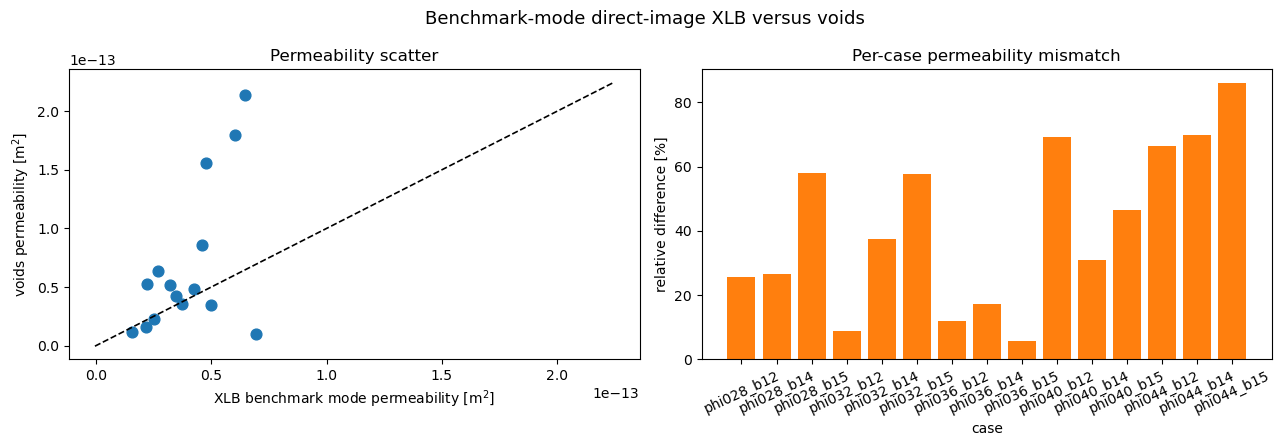

,case,k_voids,k_xlb,k_rel_diff_pct,xlb_steps,xlb_converged
0,phi028_b12,1.161061e-14,1.562870e-14,25.709728,450,True
1,phi028_b14,1.597937e-14,2.174027e-14,26.498736,400,True
2,phi028_b15,5.234643e-14,2.198064e-14,58.009283,400,True
3,phi032_b12,2.307613e-14,2.530577e-14,8.810789,2750,True
4,phi032_b14,5.138211e-14,3.215961e-14,37.410883,1250,True
5,phi032_b15,6.370653e-14,2.690397e-14,57.768901,1100,True
6,phi036_b12,4.851124e-14,4.264527e-14,12.091991,1050,True
7,phi036_b14,4.214173e-14,3.482188e-14,17.369602,2300,True
8,phi036_b15,3.517147e-14,3.732687e-14,5.774398,450,True
9,phi040_b12,1.560625e-13,4.788782e-14,69.314981,1850,True


In [8]:
_make_permeability_comparison_figure(
    summary_df,
    k_col="k_xlb",
    rel_diff_col="k_rel_diff_pct",
    xlb_label="XLB benchmark mode",
    title="Benchmark-mode direct-image XLB versus voids",
    output_path=comparison_figure_path,
)

summary_df.loc[
    :, ["case", "k_voids", "k_xlb", "k_rel_diff_pct", "xlb_steps", "xlb_converged"]
]

## Standard benchmark-mode porosity trend

This view checks whether the extracted-network workflow follows the same overall
porosity-permeability trend as the direct-image benchmark-mode XLB reference.

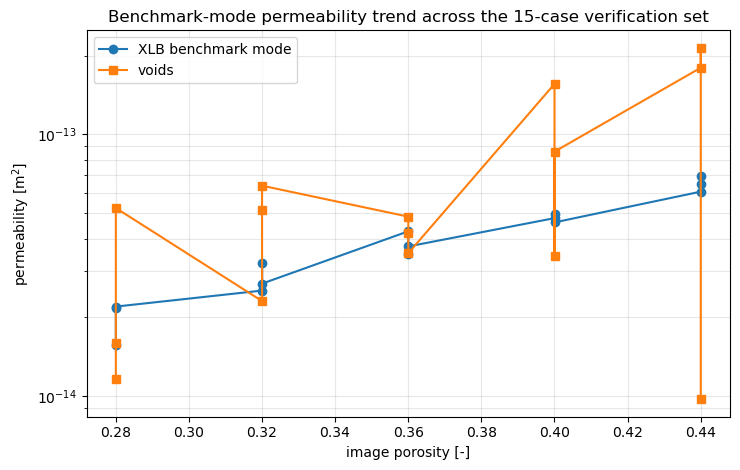

In [9]:
_make_porosity_trend_figure(
    summary_df,
    k_col="k_xlb",
    xlb_label="XLB benchmark mode",
    title="Benchmark-mode permeability trend across the 15-case verification set",
    output_path=porosity_figure_path,
)

## Steady Stokes-limit permeability comparison

The same 15 cases are also rerun with `XLBOptions.steady_stokes_defaults()`. This does not swap
to a different PDE solver. It uses the same LBM operator with a smaller shared physical pressure
drop and tighter convergence controls so the solution can be interpreted more cleanly in the
creeping-flow limit.

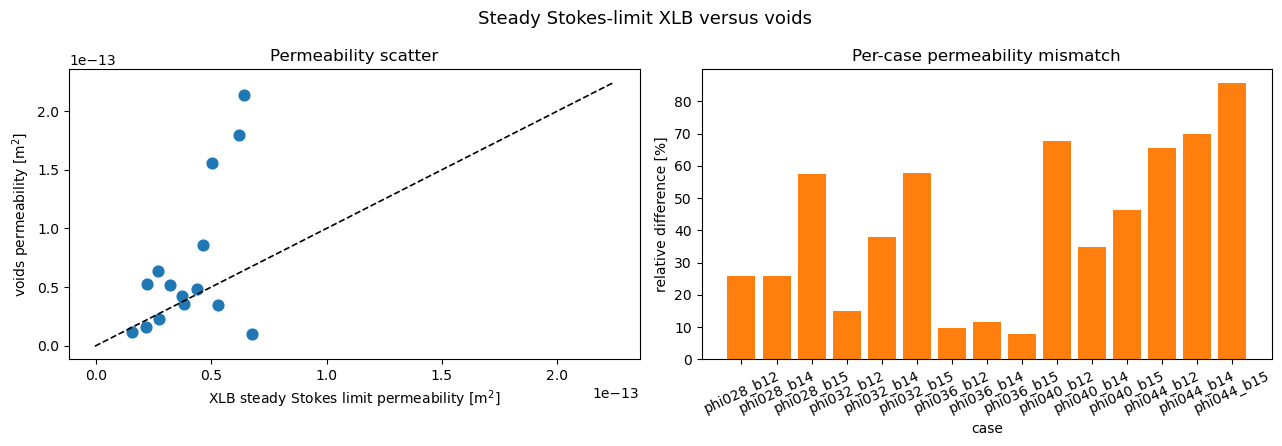

,case,k_voids,k_xlb_stokes,k_rel_diff_stokes_pct,xlb_steps_stokes,xlb_converged_stokes,xlb_mach_max_stokes,xlb_re_voxel_max_stokes
0,phi028_b12,1.161061e-14,1.564939e-14,25.807912,800,True,0.000032,0.000187
1,phi028_b14,1.597937e-14,2.159065e-14,25.989394,1100,True,0.000036,0.000210
2,phi028_b15,5.234643e-14,2.223442e-14,57.524482,1250,True,0.000031,0.000178
3,phi032_b12,2.307613e-14,2.719255e-14,15.138038,1800,True,0.000038,0.000221
4,phi032_b14,5.138211e-14,3.194141e-14,37.835548,950,True,0.000038,0.000221
5,phi032_b15,6.370653e-14,2.692458e-14,57.736541,1200,True,0.000026,0.000148
6,phi036_b12,4.851124e-14,4.385934e-14,9.589332,1550,True,0.000030,0.000173
7,phi036_b14,4.214173e-14,3.720925e-14,11.704494,850,True,0.000028,0.000162
8,phi036_b15,3.517147e-14,3.818458e-14,7.890900,1350,True,0.000034,0.000194
9,phi040_b12,1.560625e-13,5.025046e-14,67.801075,800,True,0.000030,0.000176


In [10]:
_make_permeability_comparison_figure(
    stokes_summary_df,
    k_col="k_xlb_stokes",
    rel_diff_col="k_rel_diff_stokes_pct",
    xlb_label="XLB steady Stokes limit",
    title="Steady Stokes-limit XLB versus voids",
    output_path=stokes_comparison_figure_path,
)

stokes_summary_df.loc[
    :,
    [
        "case",
        "k_voids",
        "k_xlb_stokes",
        "k_rel_diff_stokes_pct",
        "xlb_steps_stokes",
        "xlb_converged_stokes",
        "xlb_mach_max_stokes",
        "xlb_re_voxel_max_stokes",
    ],
]

## Steady Stokes-limit porosity trend

This is the same porosity-permeability comparison, but using the lower-inertia Stokes-limit
configuration of the XLB benchmark.

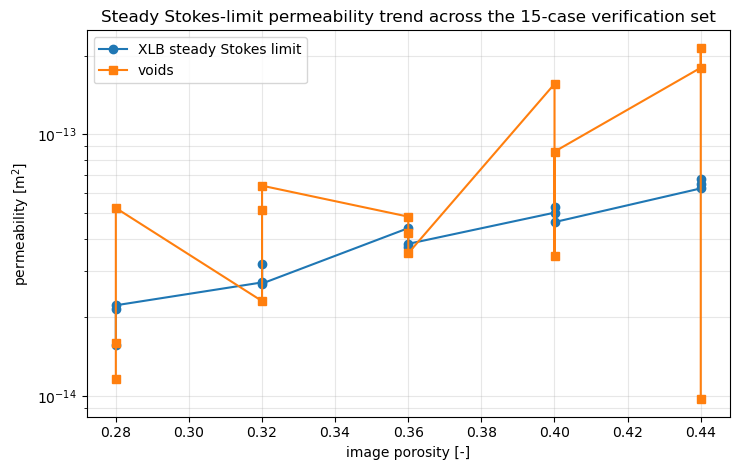

In [11]:
_make_porosity_trend_figure(
    stokes_summary_df,
    k_col="k_xlb_stokes",
    xlb_label="XLB steady Stokes limit",
    title="Steady Stokes-limit permeability trend across the 15-case verification set",
    output_path=stokes_porosity_figure_path,
)

## Benchmark-mode versus steady Stokes-limit sensitivity

This figure isolates the forcing sensitivity of the direct-image LBM reference itself. Small
differences indicate that the original benchmark settings were already close to the creeping-flow
regime for those cases.

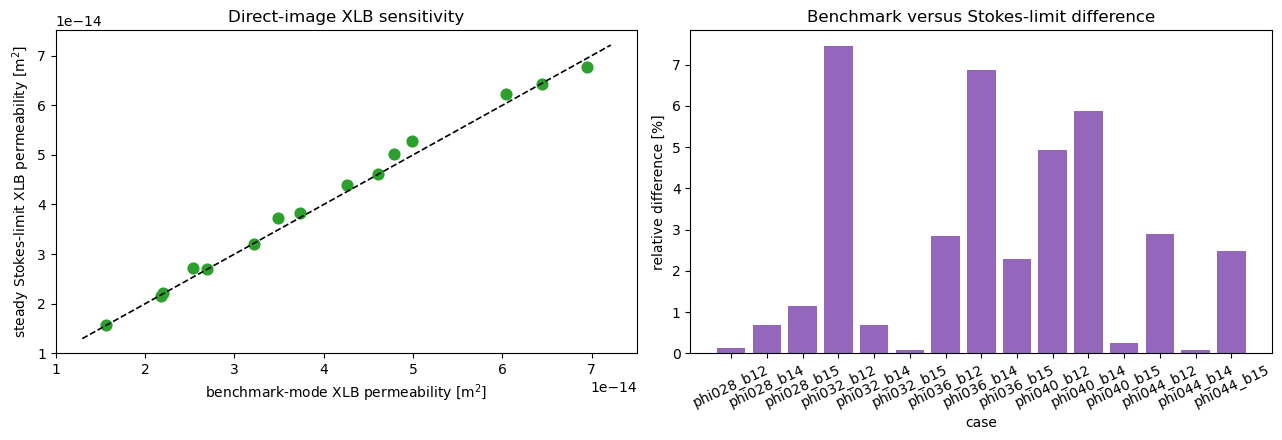

,case,k_xlb_benchmark,k_xlb_stokes,k_xlb_rel_diff_pct_benchmark_vs_stokes,xlb_mach_max_stokes,xlb_re_voxel_max_stokes
0,phi028_b12,1.562870e-14,1.564939e-14,0.132338,0.000032,0.000187
1,phi028_b14,2.174027e-14,2.159065e-14,0.688201,0.000036,0.000210
2,phi028_b15,2.198064e-14,2.223442e-14,1.154544,0.000031,0.000178
3,phi032_b12,2.530577e-14,2.719255e-14,7.455930,0.000038,0.000221
4,phi032_b14,3.215961e-14,3.194141e-14,0.678497,0.000038,0.000221
5,phi032_b15,2.690397e-14,2.692458e-14,0.076627,0.000026,0.000148
6,phi036_b12,4.264527e-14,4.385934e-14,2.846907,0.000030,0.000173
7,phi036_b14,3.482188e-14,3.720925e-14,6.855962,0.000028,0.000162
8,phi036_b15,3.732687e-14,3.818458e-14,2.297820,0.000034,0.000194
9,phi040_b12,4.788782e-14,5.025046e-14,4.933696,0.000030,0.000176


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

kmin = float(
    min(
        stokes_summary_df["k_xlb_benchmark"].min(),
        stokes_summary_df["k_xlb_stokes"].min(),
    )
)
kmax = float(
    max(
        stokes_summary_df["k_xlb_benchmark"].max(),
        stokes_summary_df["k_xlb_stokes"].max(),
    )
)
pad = 0.05 * max(kmax - kmin, 1.0e-30)

axes[0].scatter(
    stokes_summary_df["k_xlb_benchmark"],
    stokes_summary_df["k_xlb_stokes"],
    s=60,
    color="tab:green",
)
axes[0].plot(
    [kmin - pad, kmax + pad],
    [kmin - pad, kmax + pad],
    color="black",
    lw=1.2,
    linestyle="--",
)
axes[0].set_xlabel("benchmark-mode XLB permeability [m$^2$]")
axes[0].set_ylabel("steady Stokes-limit XLB permeability [m$^2$]")
axes[0].set_title("Direct-image XLB sensitivity")

axes[1].bar(
    stokes_summary_df["case"],
    stokes_summary_df["k_xlb_rel_diff_pct_benchmark_vs_stokes"],
    color="tab:purple",
)
axes[1].set_xlabel("case")
axes[1].set_ylabel("relative difference [%]")
axes[1].set_title("Benchmark versus Stokes-limit difference")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
fig.savefig(benchmark_vs_stokes_figure_path, dpi=160, bbox_inches="tight")
plt.show()

stokes_summary_df.loc[
    :,
    [
        "case",
        "k_xlb_benchmark",
        "k_xlb_stokes",
        "k_xlb_rel_diff_pct_benchmark_vs_stokes",
        "xlb_mach_max_stokes",
        "xlb_re_voxel_max_stokes",
    ],
]

## Notes

Useful follow-up checks if the mismatch is larger than expected:

- tighten XLB convergence controls (`max_steps`, `check_interval`, `steady_rtol`)
- inspect whether the segmented geometry is too coarse for the direct-image solve
- compare against multiple conductance models on the `voids` side
- repeat on larger synthetic samples to reduce inlet/outlet and discretization effects